In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

List of .json files in https://github.com/prust/wikipedia-movie-data/tree/master.
Number of datasets: 5 datasets.

In [28]:
list_of_years = np.arange(1920, 2020, 20)
json_main = 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/refs/heads/master/'

full_list=[]
for year in list_of_years:
  file_name = f'{json_main}movies-{year}s.json'
  full_list.append(file_name)

print(f'Downloaded {len(full_list)} files')

Downloaded 5 files


Read each file as a JSON object. 
Remove unnecessary columns: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']. 
Keep only complete rows. 
Combine data from all files into a single dataset.
The size of the final dataset should include 4 columns.

In [29]:
data = []
columns_to_drop = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

for file in full_list:
  temp_df = pd.read_json(file)
  temp_df = temp_df.drop(columns=columns_to_drop, errors='ignore')
  data.append(temp_df)

movies_df = pd.concat(data)
movies_df.info()
print('Shape:', movies_df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 16339 entries, 0 to 2429
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   16339 non-null  object
 1   year    16339 non-null  int64 
 2   cast    16339 non-null  object
 3   genres  16339 non-null  object
dtypes: int64(1), object(3)
memory usage: 638.2+ KB
Shape: (16339, 4)


In [30]:
movies_df.head()

,title,year,cast,genres
0,813,1920,"[Wedgwood Nowell, Ralph Lewis, Wallace Beery, ...",[Mystery]
1,The Adorable Savage,1920,"[Edith Roberts, Jack Perrin]","[Romance, Adventure, Drama, Silent]"
2,The Adventurer,1920,"[William Farnum, Estelle Taylor]",[Historical]
3,Alarm Clock Andy,1920,"[Charles Ray, George Webb]","[Comedy, Silent]"
4,Alias Jimmy Valentine,1920,"[Bert Lytell, Vola Vale, Eugene Pallette]","[Crime, Drama, Silent]"


Found the top 10 genres by number of films. 

In [31]:
movies_df_genres = movies_df.explode('genres')
movies_df_genres

,title,year,cast,genres
0,813,1920,"[Wedgwood Nowell, Ralph Lewis, Wallace Beery, ...",Mystery
1,The Adorable Savage,1920,"[Edith Roberts, Jack Perrin]",Romance
1,The Adorable Savage,1920,"[Edith Roberts, Jack Perrin]",Adventure
1,The Adorable Savage,1920,"[Edith Roberts, Jack Perrin]",Drama
1,The Adorable Savage,1920,"[Edith Roberts, Jack Perrin]",Silent
...,...,...,...,...
2427,Sherlock Holmes,2009,"[Robert Downey Jr., Jude Law, Rachel McAdams, ...",Action
2427,Sherlock Holmes,2009,"[Robert Downey Jr., Jude Law, Rachel McAdams, ...",Mystery
2427,Sherlock Holmes,2009,"[Robert Downey Jr., Jude Law, Rachel McAdams, ...",Historical
2428,The Loss of a Teardrop Diamond,2009,"[Bryce Dallas Howard, Chris Evans, Ellen Burst...",Independent


In [32]:
genre_count = movies_df_genres['genres'].value_counts().reset_index()
genre_count.columns = ['Genres', 'Count']
top_ten_genres = genre_count[:10]
top_ten_genres

,Genres,Count
0,Drama,5963
1,Comedy,4910
2,Silent,4470
3,Western,2341
4,Romance,1332
5,Crime,1071
6,Action,934
7,Musical,842
8,War,826
9,Thriller,783


Created a bar chart and a pie chart, and displayed a summary table.

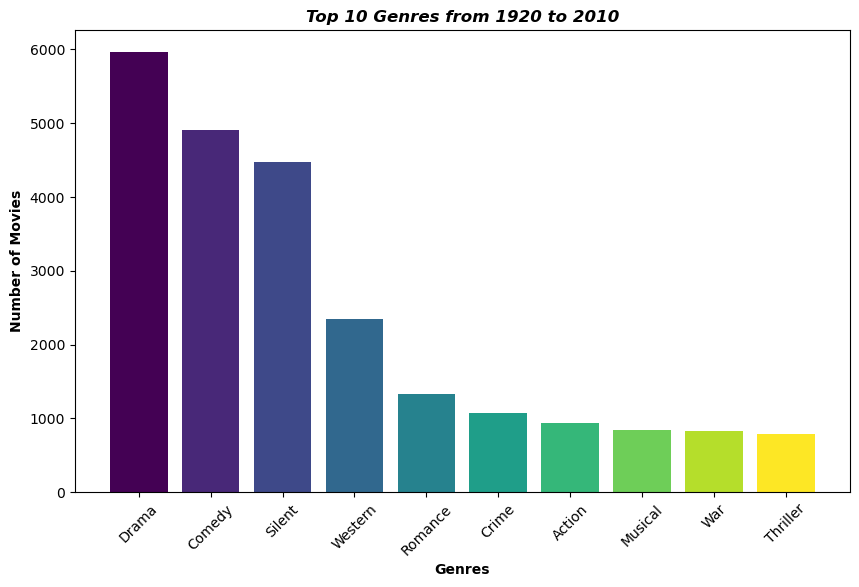

In [33]:
plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0,1,10))

plt.bar(top_ten_genres['Genres'],
        top_ten_genres['Count'],
        color=colors
    )
plt.xticks(rotation=45)
plt.title('Top 10 Genres from 1920 to 2010', fontstyle='italic', fontweight='bold')
plt.xlabel('Genres', fontweight='bold')
plt.ylabel('Number of Movies', fontweight='bold')

plt.show()

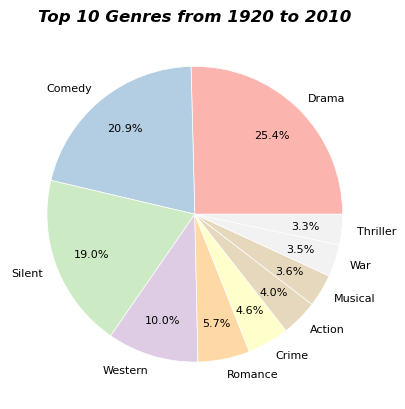

In [34]:
cmap = plt.get_cmap('Pastel1')
colors = cmap(np.linspace(0,1,10))

plt.pie(
    x=top_ten_genres['Count'],
    labels=top_ten_genres['Genres'],
    colors=colors,
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'white',
                'linewidth': 0.5},
    pctdistance=0.75,
    textprops={'fontsize': 8}
)

plt.title('Top 10 Genres from 1920 to 2010', fontstyle='italic', fontweight='bold')
plt.show()

Selected the 3 most popular genres and tracked how their popularity changed over the selected time period.

In [35]:
popular_genres = ['Drama','Comedy', 'Silent']
movies_df_popular = movies_df_genres[movies_df_genres['genres'].isin(popular_genres)].copy()
movies_df_popular.drop(['cast', 'title'], axis=1, inplace=True)
movies_df_popular = movies_df_popular.groupby(['genres', 'year']).value_counts().reset_index()
movies_df_popular

,genres,year,count
0,Comedy,1920,149
1,Comedy,1921,155
2,Comedy,1922,123
3,Comedy,1923,96
4,Comedy,1924,98
...,...,...,...
109,Silent,1929,95
110,Silent,1945,1
111,Silent,1947,1
112,Silent,1969,1


In [36]:
pivot_data = movies_df_popular.pivot(index='year', columns='genres', values='count').fillna(0).reset_index()

pivot_data

genres,year,Comedy,Drama,Silent
0,1920,149.0,380.0,484.0
1,1921,155.0,341.0,508.0
2,1922,123.0,297.0,441.0
3,1923,96.0,271.0,391.0
4,1924,98.0,301.0,452.0
5,1925,138.0,329.0,564.0
6,1926,177.0,235.0,534.0
7,1927,203.0,242.0,519.0
8,1928,166.0,281.0,478.0
9,1929,109.0,220.0,95.0


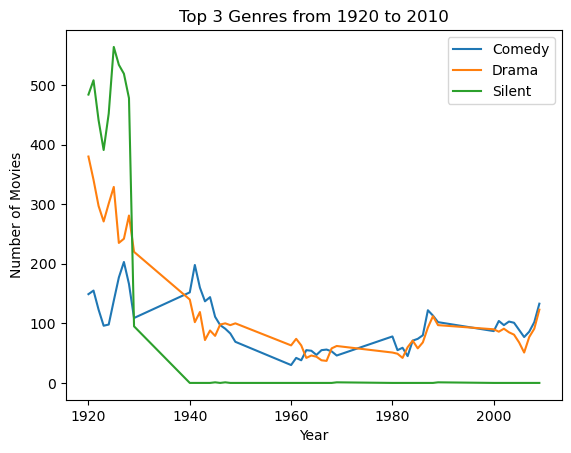

In [37]:
plt.plot(pivot_data['year'], pivot_data[['Comedy', 'Drama', 'Silent']])
plt.legend(['Comedy', 'Drama', 'Silent'], loc='upper right')
plt.title('Top 3 Genres from 1920 to 2010')
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

Found the top 10 actors by number of films. 

In [38]:
movies_df_actors = movies_df.explode('cast')
movies_df_actors

actor_count = movies_df_actors['cast'].value_counts().reset_index()
actor_count.columns = ['Actors', 'Count']
top_ten_actors = actor_count[:10]
top_ten_actors

,Actors,Count
0,Hoot Gibson,122
1,Johnny Mack Brown,84
2,Raymond Hatton,78
3,Charles Starrett,76
4,Buck Jones,71
5,Tom Mix,68
6,Wallace Beery,64
7,Roy Rogers,61
8,Richard Dix,60
9,Irene Rich,59


Created a bar chart and displayed a summary table.

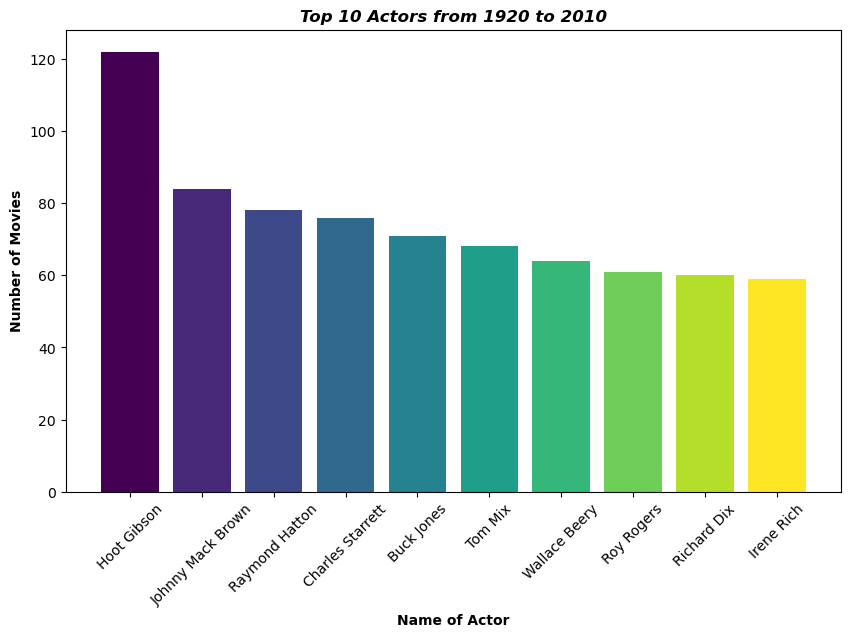

In [39]:
plt.figure(figsize=(10, 6))
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0,1,10))

plt.bar(top_ten_actors['Actors'],
        top_ten_actors['Count'],
        color=colors
    )
plt.xticks(rotation=45)
plt.title('Top 10 Actors from 1920 to 2010', fontstyle='italic', fontweight='bold')
plt.xlabel('Name of Actor', fontweight='bold')
plt.ylabel('Number of Movies', fontweight='bold')

plt.show()

Selected the 3 most popular actors and tracked how their popularity changed over the selected time period.

In [40]:
popular_actors = ['Hoot Gibson','Johnny Mack Brown', 'Raymond Hatton']
movies_df_popular_actors = movies_df_actors[movies_df_actors['cast'].isin(popular_actors)].copy()
movies_df_popular_actors.drop(['genres', 'title'], axis=1, inplace=True)
movies_df_popular_actors = movies_df_popular_actors.groupby(['cast', 'year']).value_counts().reset_index()
movies_df_popular_actors

,cast,year,count
0,Hoot Gibson,1920,33
1,Hoot Gibson,1921,19
2,Hoot Gibson,1922,8
3,Hoot Gibson,1923,10
4,Hoot Gibson,1924,7
5,Hoot Gibson,1925,5
6,Hoot Gibson,1926,7
7,Hoot Gibson,1927,7
8,Hoot Gibson,1928,8
9,Hoot Gibson,1929,7


In [42]:
pivot_data_actors = movies_df_popular_actors.pivot(index='year', columns='cast', values='count').fillna(0).reset_index()

pivot_data_actors

cast,year,Hoot Gibson,Johnny Mack Brown,Raymond Hatton
0,1920,33.0,0.0,1.0
1,1921,19.0,0.0,4.0
2,1922,8.0,0.0,4.0
3,1923,10.0,0.0,2.0
4,1924,7.0,0.0,2.0
5,1925,5.0,0.0,1.0
6,1926,7.0,0.0,5.0
7,1927,7.0,1.0,3.0
8,1928,8.0,4.0,2.0
9,1929,7.0,3.0,0.0


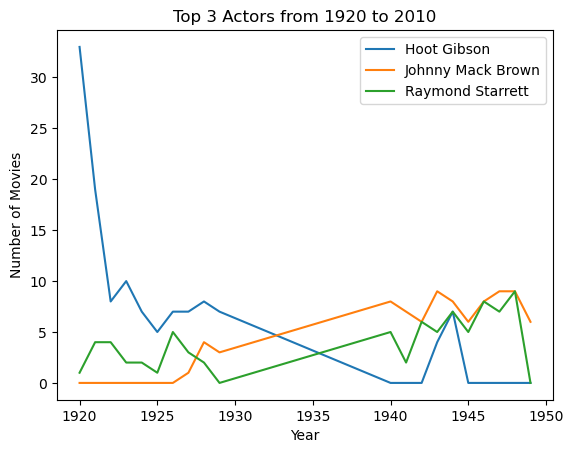

In [43]:
plt.plot(pivot_data_actors['year'], pivot_data_actors[['Hoot Gibson','Johnny Mack Brown', 'Raymond Hatton']])
plt.title("Top 3 Actors from 1920 to 2010")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.legend(['Hoot Gibson','Johnny Mack Brown', 'Raymond Starrett'], loc='upper right')

plt.show()

How often each actor appears in films from the top 3 most popular genres, and how often they appear in films outside those genres.

In [51]:
top_genres = ['Drama', 'Comedy', 'Silent']
top_10_actors = ['Hoot Gibson', 'Johnny Mack Brown', 'Raymond Hatton', 'Charles Starrett', 'Buck Jones', 'Tom Mix', 'Wallace Beery', 'Roy Rogers', 'Richard Dix', 'Irene Rich']

movies_df_genres['top_genre'] = movies_df_genres['genres'].isin(top_genres)
movies_df_actors = movies_df_genres.explode('cast')
movies_df_actors['top_actors']= movies_df_actors['cast'].isin(top_10_actors)

only_top_actors = movies_df_actors[movies_df_actors['top_actors'] == True].copy()
only_top_actors.drop(['title', 'year', 'genres', 'top_actors'], axis=1, inplace=True)
only_top_actors

,cast,top_genre
0,Wallace Beery,False
80,Tom Mix,False
80,Tom Mix,False
80,Tom Mix,True
88,Tom Mix,False
...,...,...
4443,Johnny Mack Brown,False
4452,Roy Rogers,False
4471,Johnny Mack Brown,False
4482,Johnny Mack Brown,False


In [48]:
number_of_movies = only_top_actors.pivot_table(
    index='cast', columns='top_genre', aggfunc='size', fill_value=0
)
number_of_movies.columns = ['not_pop', 'pop']
number_of_movies.reset_index(inplace=True)
number_of_movies


,cast,not_pop,pop
0,Buck Jones,79,55
1,Charles Starrett,80,0
2,Hoot Gibson,176,116
3,Irene Rich,24,94
4,Johnny Mack Brown,80,15
5,Raymond Hatton,70,39
6,Richard Dix,53,75
7,Roy Rogers,67,1
8,Tom Mix,76,70
9,Wallace Beery,43,88


In [49]:
number_of_movies['total_movies'] = (number_of_movies['not_pop']) + (number_of_movies['pop'])
number_of_movies['top_perc_%'] = (((number_of_movies['pop']) / (number_of_movies['total_movies']))*100).round(2)
number_of_movies

,cast,not_pop,pop,total_movies,top_perc_%
0,Buck Jones,79,55,134,41.04
1,Charles Starrett,80,0,80,0.00
2,Hoot Gibson,176,116,292,39.73
3,Irene Rich,24,94,118,79.66
4,Johnny Mack Brown,80,15,95,15.79
5,Raymond Hatton,70,39,109,35.78
6,Richard Dix,53,75,128,58.59
7,Roy Rogers,67,1,68,1.47
8,Tom Mix,76,70,146,47.95
9,Wallace Beery,43,88,131,67.18


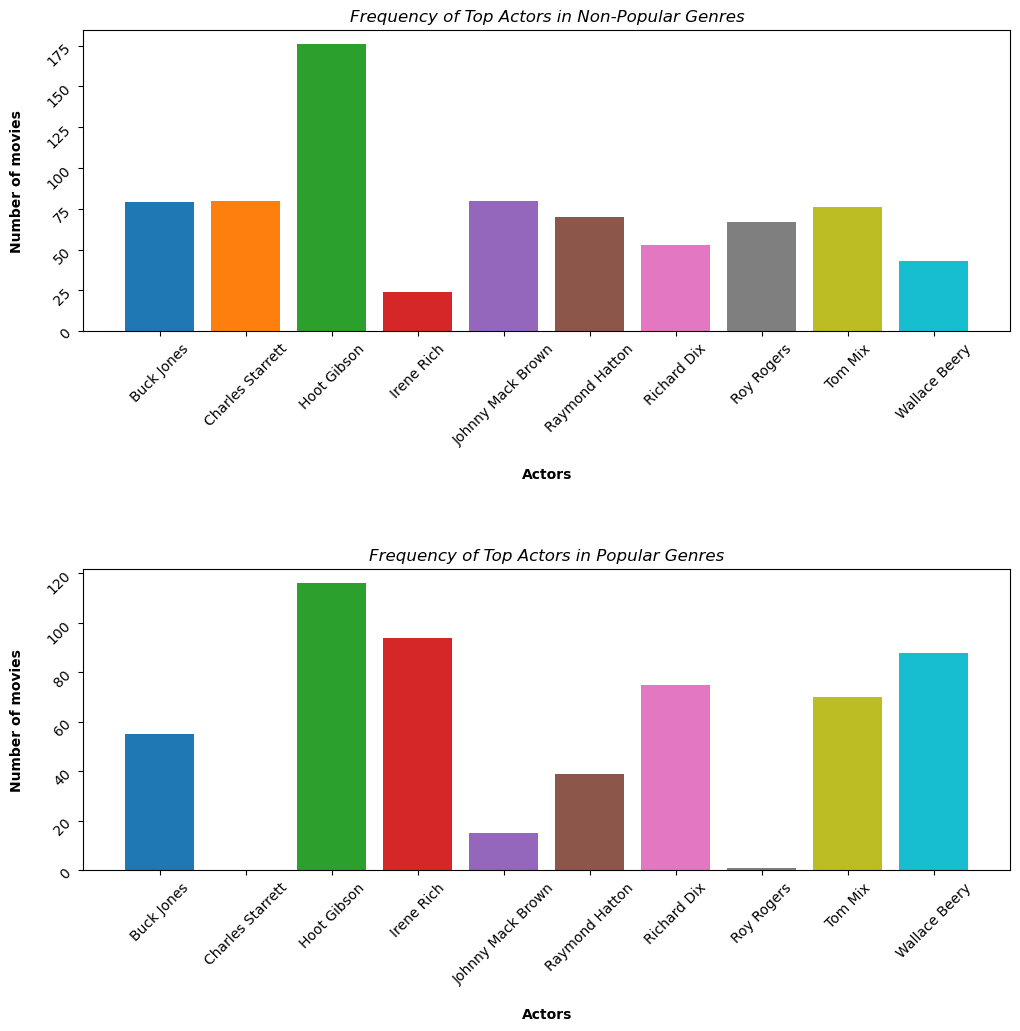

In [50]:
fig, ax = plt.subplots(nrows=2, figsize=(10,9))
fig.tight_layout(h_pad=15, w_pad=10)
cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0,1,10))


ax[0].bar(number_of_movies['cast'], number_of_movies['not_pop'], color=colors)
ax[0].set_xlabel('Actors', labelpad=15, fontweight='bold')
ax[0].set_ylabel('Number of movies', labelpad=15, fontweight='bold')
ax[0].set_title('Frequency of Top Actors in Non-Popular Genres', fontstyle='italic')
ax[0].tick_params(rotation=45)

ax[1].bar(number_of_movies['cast'], number_of_movies['pop'], color=colors)
ax[1].set_xlabel('Actors', labelpad=15, fontweight='bold')
ax[1].set_ylabel('Number of movies',labelpad=15, fontweight='bold')
ax[1].set_title('Frequency of Top Actors in Popular Genres', fontstyle='italic')
ax[1].tick_params(rotation=45)
plt.show()